#  Michelson interferometers with power recycling

A simple Michelson interferometer operated on the **dark fringe** reflects nearly all of the incident laser light back toward the laser source. Although this operating point is ideal for detecting differential arm length changes (such as those caused by gravitational waves), it means that very little carrier light remains inside the interferometer.

This reflected light can instead be reused by placing a partially transmitting mirror at the input port, known as the **Power Recycling Mirror (PRM)**. Together, the PRM and the Michelson interferometer form a **power recycling cavity (PRC)**.

When the PRC is tuned to resonance, the light reflected by the Michelson constructively interferes with the incoming laser field. As a result, the optical power circulating inside the interferometer becomes much larger than the input laser power. This increased circulating power improves the detector sensitivity by reducing photon shot noise without requiring a more powerful laser.

The amount of power buildup depends mainly on

- the reflectivity of the power recycling mirror,
- the tuning (phase) of the PRM, and
- optical losses inside the interferometer.

The first simulation demonstrates how the circulating power inside the recycling cavity varies as the PRM tuning is scanned. The resonance of the recycling cavity appears as a sharp peak in the circulating power. 

c:\Users\ABC\miniconda3\envs\finesse3-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


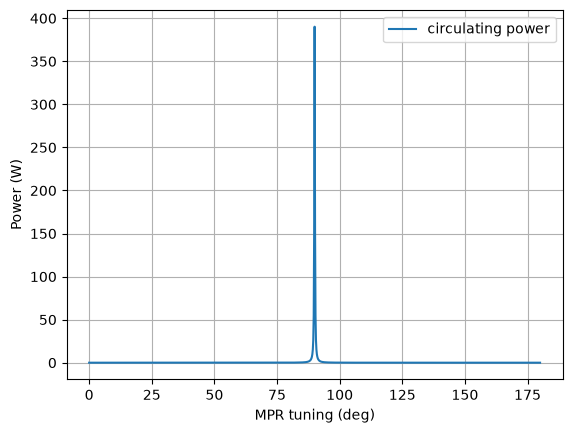

In [1]:
import finesse
from finesse.analysis.actions import Xaxis
import numpy as np
import matplotlib.pyplot as plt

model = finesse.Model()
model.parse("""
l L0 P=1
s s1 L0.p1 MPR.p1 L=1
m MPR R=0.99 T=0.01 phi=0     # start at 0, we'll scan this

s s2 MPR.p2 BS.p1 L=1
bs BS R=0.5 T=0.5 phi=0 alpha=45

s syarm BS.p3 ETMy.p1 L=600
m ETMy T=100e-6 L=0 phi=0

s sxarm BS.p2 ETMx.p1 L=600
m ETMx T=100e-6 L=0 phi=90

pd circ MPR.p2.o             # circulating power inside recycling cavity
""")

out = model.run(Xaxis("MPR.phi", "lin", 0, 180, 1000))

plt.plot(out.x[0], np.abs(out['circ']), label='circulating power')
plt.xlabel('MPR tuning (deg)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid()
plt.show()

From the circulating power plot, the maximum power buildup is observed at a PRM tuning of $\varphi=90^\circ$. This corresponds to the resonance condition of the power recycling cavity, where the light reflected by the Michelson interferometer constructively interferes with the incoming laser field. Consequently, the power recycling mirror should be tuned to $\varphi=90^\circ$ to maximize the intracavity power and ensure efficient operation of the power-recycled Michelson interferometer.

The second simulation compares the frequency response of three Michelson interferometers:

- **No power recycling mirror**
- **Power recycling mirror with \(R=0.9\)**
- **Power recycling mirror with \(R=0.99\)**

A differential phase modulation is injected into the two interferometer arms to mimic a gravitational-wave signal. The upper signal sideband emerging from the dark port is then measured while sweeping the signal frequency.

Increasing the reflectivity of the PRM increases the carrier power stored inside the interferometer. Since the gravitational-wave sidebands are proportional to the circulating carrier field, a higher recycling gain results in a larger detected signal over most of the frequency range.

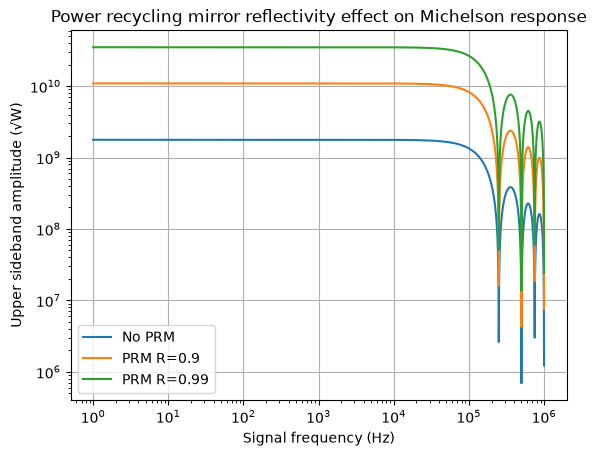

In [2]:
import finesse
from finesse.analysis.actions import Xaxis

model0 = finesse.Model()
model0.parse("""
l L0 P=1                     # 1 W input laser        
s s1 L0.p1 BS.p1 L=1        # laser -> beamsplitter

bs BS R=0.5 T=0.5 phi=0 alpha=45

s syarm BS.p3 ETMy.p1 L=600   # Y arm, reflected off BS
m ETMy T=100e-6 L=0 phi=0     # Y end mirror

s sxarm BS.p2 ETMx.p1 L=600   # X arm, transmitted through BS
m ETMx T=100e-6 L=0 phi=90    # X end mirror, tuned to the dark fringe

# Inject a common signal into both arms, 180 deg out of phase
# -- this *is* the gravitational-wave strain
sgen sigY syarm.h phase=180
sgen sigX sxarm.h phase=0
fsig(1)                       # initial signal frequency (will be swept)

# Track the upper signal sideband at the dark port
ad upper node=BS.p4.o f=fsig.f
""")

model1 = finesse.Model()
model1.parse("""
l L0 P=1                     # 1 W input laser
s s1 L0.p1 MPR.p1 L=1        # laser -> power recycling mirror
m MPR R=0.9 T=0.1 phi=90          # power recycling mirror           
s s2 MPR.p2 BS.p1 L=1        # laser -> beamsplitter

bs BS R=0.5 T=0.5 phi=0 alpha=45

s syarm BS.p3 ETMy.p1 L=600   # Y arm, reflected off BS
m ETMy T=100e-6 L=0 phi=0     # Y end mirror

s sxarm BS.p2 ETMx.p1 L=600   # X arm, transmitted through BS
m ETMx T=100e-6 L=0 phi=90    # X end mirror, tuned to the dark fringe

# Inject a common signal into both arms, 180 deg out of phase
# -- this *is* the gravitational-wave strain
sgen sigY syarm.h phase=180
sgen sigX sxarm.h phase=0
fsig(1)                       # initial signal frequency (will be swept)

# Track the upper signal sideband at the dark port
ad upper node=BS.p4.o f=fsig.f
""")

model2 = finesse.Model()
model2.parse("""
l L0 P=1                     # 1 W input laser
s s1 L0.p1 MPR.p1 L=1        # laser -> power recycling mirror
m MPR R=0.99 T=0.01 phi=90          # power recycling mirror           
s s2 MPR.p2 BS.p1 L=1        # laser -> beamsplitter

bs BS R=0.5 T=0.5 phi=0 alpha=45

s syarm BS.p3 ETMy.p1 L=600   # Y arm, reflected off BS
m ETMy T=100e-6 L=0 phi=0     # Y end mirror

s sxarm BS.p2 ETMx.p1 L=600   # X arm, transmitted through BS
m ETMx T=100e-6 L=0 phi=90    # X end mirror, tuned to the dark fringe

# Inject a common signal into both arms, 180 deg out of phase
# -- this *is* the gravitational-wave strain
sgen sigY syarm.h phase=180
sgen sigX sxarm.h phase=0
fsig(1)                       # initial signal frequency (will be swept)

# Track the upper signal sideband at the dark port
ad upper node=BS.p4.o f=fsig.f
""")

out0 = model0.run(Xaxis("fsig.f", "log", 1, 1e6, 4000))
out1 = model1.run(Xaxis("fsig.f", "log", 1, 1e6, 4000))
out2 = model2.run(Xaxis("fsig.f", "log", 1, 1e6, 4000))

import numpy as np
import matplotlib.pyplot as plt

plt.plot(out0.x[0], np.abs(out0['upper']), label='No PRM')
plt.plot(out1.x[0], np.abs(out1['upper']), label='PRM R=0.9')
plt.plot(out2.x[0], np.abs(out2['upper']), label='PRM R=0.99')

plt.xlabel('Signal frequency (Hz)')
plt.ylabel('Upper sideband amplitude (√W)')
plt.title('Power recycling mirror reflectivity effect on Michelson response')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()